In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [23]:
df = pd.read_csv("sales.csv")

print("Kolom Asli Dataset:")
print(df.columns)


Kolom Asli Dataset:
Index(['order_id', 'date', 'store', 'product', 'quantity', 'sales'], dtype='object')


In [8]:
df.head()

,order_id,date,store,product,quantity,sales
0,1,01/01/2023,Lower Manhattan,Gourmet brewed coffee,2,6.0
1,2,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2
2,3,01/01/2023,Lower Manhattan,Hot chocolate,2,9.0
3,4,01/01/2023,Lower Manhattan,Drip coffee,1,2.0
4,5,01/01/2023,Lower Manhattan,Brewed Chai tea,2,6.2


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149116 entries, 0 to 149115
Data columns (total 6 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   order_id  149116 non-null  int64  
 1   date      149116 non-null  object 
 2   store     149116 non-null  object 
 3   product   149116 non-null  object 
 4   quantity  149116 non-null  int64  
 5   sales     149116 non-null  float64
dtypes: float64(1), int64(2), object(3)
memory usage: 6.8+ MB


In [10]:
df.describe()

,order_id,quantity,sales
count,149116.000000,149116.000000,149116.000000
mean,74737.371872,1.438276,4.686367
std,43153.600016,0.542509,4.227099
min,1.000000,1.000000,0.800000
25%,37335.750000,1.000000,3.000000
50%,74727.500000,1.000000,3.750000
75%,112094.250000,2.000000,6.000000
max,149456.000000,8.000000,360.000000


In [17]:
import pandas as pd

df = pd.read_csv("sales.csv")

print("Jumlah kolom:", len(df.columns))
print("Daftar kolom asli:")
for col in df.columns:
    print(repr(col))

Jumlah kolom: 6
Daftar kolom asli:
'order_id'
'date'
'store'
'product'
'quantity'
'sales'


In [29]:
print(df.columns)

Index(['order_id', 'date', 'store', 'product', 'quantity', 'sales'], dtype='object')


In [41]:
df['date'] = pd.to_datetime(df['date'], errors='coerce')

In [42]:
monthly_sales = df.groupby(df['date'].dt.to_period('M'))['sales'].sum().reset_index()

print("\n4. Data Tren Bulanan:")
print(monthly_sales.head())


4. Data Tren Bulanan:
      date     sales
0  2023-01  21673.10
1  2023-02  21164.15
2  2023-03  21797.80
3  2023-04  20455.85
4  2023-05  20833.70


ANALYTICAL QUESTIONS

1. Berapa total revenue keseluruhan?
2. Produk apa yang paling banyak terjual?
3. Negara mana dengan revenue terbesar?
4. Bagaimana tren penjualan per bulan?
5. Apa store dengan total transaksi terbanyak?
6. Bulan apa dengan penjualan tertinggi?
7. Apakah ada perbedaan pola pembelian antar negara?

In [47]:
# 1. TOTAL REVENUE KESELURUHAN
total_revenue = df['sales'].sum()
print("\n1. Total Revenue Keseluruhan:")
print(total_revenue)


1. Total Revenue Keseluruhan:
698812.3300000001


task pertama ini untuk menunjukkan total revenue keseluruhan yang dimana di bagian ini aku hitung total seluruh pendapatan dari data penjualan yang ada, tujuannya buat tau berapa total pemasukan yang dihasilkan secara keseluruhan.

In [31]:
# 2. Produk paling laris
top_product = df.groupby('product')['quantity'].sum().sort_values(ascending=False)

print("\n2. Produk Paling Banyak Terjual:")
print(top_product.head(10))


2. Produk Paling Banyak Terjual:
product
Brewed Chai tea          26250
Gourmet brewed coffee    25973
Barista Espresso         24943
Brewed Black tea         17462
Hot chocolate            17457
Brewed herbal tea        17328
Organic brewed coffee    13012
Drip coffee              12891
Premium brewed coffee    12431
Scone                    10465
Name: quantity, dtype: int64


di sini aku cari produk mana yang paling banyak dibeli berdasarkan jumlah quantity, dari hasil ini kita bisa tau produk mana yang paling laku.

In [33]:
# 3. Negara dengan revenue terbesar
top_store = df.groupby('store')['sales'].sum().sort_values(ascending=False)

print("\n3. Store dengan Revenue Terbesar:")
print(top_store)


3. Store dengan Revenue Terbesar:
store
Hell's Kitchen     236511.17
Astoria            232243.91
Lower Manhattan    230057.25
Name: sales, dtype: float64


data dikelompokkan berdasarkan negara, lalu dijumlahkan total sales-nya, tujuannya buat lihat negara mana yang kontribusi penjualannya paling besar.

In [45]:
# 4. Tren penjualan per bulan
monthly_sales = df.groupby(df['date'].dt.to_period('M'))['sales'].sum().reset_index()

print("\n4. Data Tren Bulanan:")
print(monthly_sales.head())



4. Data Tren Bulanan:
      date     sales
0  2023-01  21673.10
1  2023-02  21164.15
2  2023-03  21797.80
3  2023-04  20455.85
4  2023-05  20833.70


penjualan dikelompokkan berdasarkan bulan, lalu dijumlahkan totalnya setiap bulan, dari sini bisa kelihatan apakah penjualan naik, turun, atau stabil tiap bulannya.

In [38]:
# 5. Customer dengan pembelian terbesar
top_store_transaction = df.groupby('store')['order_id'].count().sort_values(ascending=False)
print("\n5. Store dengan Total Transaksi Terbanyak:")
print(top_store_transaction)



5. Store dengan Total Transaksi Terbanyak:
store
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: order_id, dtype: int64


Di bagian ini bisa bandingkan total penjualan tiap store, jadi bisa tau store mana yang performanya paling bagus.

In [46]:
# 6. Bulan dengan penjualan tertinggi
best_month = monthly_sales.sort_values('sales', ascending=False).head(1)

print("\n6. Bulan dengan Penjualan Tertinggi:")
print(best_month)


6. Bulan dengan Penjualan Tertinggi:
      date     sales
7  2023-08  25253.08


Setelah lihat tren bulanan, aku cari bulan mana yang penjualannya paling tinggi, ini bisa nunjukin periode paling ramai dalam penjualan.


7. Pola Pembelian Antar Store:
store
Lower Manhattan    71742
Hell's Kitchen     71737
Astoria            70991
Name: quantity, dtype: int64


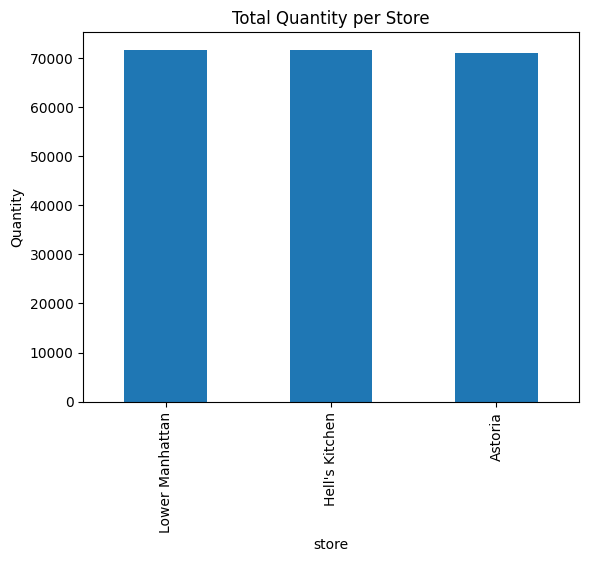

In [36]:
# 7. Pola pembelian per negara (Top 5)
store_pattern = df.groupby('store')['quantity'].sum().sort_values(ascending=False)

print("\n7. Pola Pembelian Antar Store:")
print(store_pattern)

plt.figure()
store_pattern.plot(kind='bar')
plt.title("Total Quantity per Store")
plt.ylabel("Quantity")
plt.show()

di sini aku bandingkan pola pembelian antar negara, baik dari sisi jumlah barang yang dibeli maupun total penjualannya, tujuannya buat lihat apakah tiap negara punya pola belanja yang berbeda.